### Demonstrate adding in and fitting out the track of a moving point source

This notebook accompanies arxiv:????

This notebook remakes several figures from the paper and demonstrates how to add in and fit moving point sources from up-the-ramp images.

In [1]:
import numpy as np
from astropy.io import fits
from scipy import interpolate
import movingsource

# Part of this notebook uses fitramp (https://github.com/t-brandt/fitramp)
try:
    import fitramp
    use_fitramp = True
except:
    use_fitramp = False

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import rcParams

# Formatting for plots
rcParams['font.size'] = 16
rcParams['lines.linewidth'] = 3.0
rcParams['savefig.facecolor'] = 'white'
rcParams['axes.labelsize'] = 16
rcParams['xtick.direction'] = 'in'
rcParams['xtick.minor.visible'] = True
rcParams['ytick.direction'] = 'in'
rcParams['ytick.right'] = True
rcParams['ytick.minor.visible'] = True

The code block below adds read noise and photon noise to a static image defined by `countrate`.  All units are assumed to be in electrons; `countrate` is in electrons/read.  

In [2]:
def gen_noisy_image(readtimes, resultants, countrate, sig_readnoise, phnoise=True):
    diffs = np.diff(readtimes)[:, None, None]*countrate
    diffs_with_phnoise = np.random.poisson(diffs)
    readnoise_cum = np.random.randn(len(readtimes), *countrate.shape)*sig_readnoise[None, :]
    if phnoise:
        diffs = np.diff(readnoise_cum, axis=0) + diffs_with_phnoise
    else:
        diffs = np.diff(readnoise_cum, axis=0) + diffs
        
    read_values = np.zeros((diffs.shape[0] + 1, *countrate.shape))
    read_values[1:] = np.cumsum(diffs, axis=0)
    
    values_resultants = movingsource.bin_to_resultants(read_values, resultants)
    
    return values_resultants

The code block below adds a moving source to a static background field.  The background field can have randomly positioned stars of random brightnesses.  The static background field then has noise added, and finally the track of a moving object with photon noise.  We then fit for the moving object's path and show how it may be removed from the image.

In [3]:
bkgnd_ctrate = 1    # Background level, counts/read
source_ctrate = 500 # Source flux, counts/read
star_ctrate = 30    # Maximum star flux, counts/read
nstars = 100

phi = 50*np.pi/180  # Angle in radians of the moving source's velocity w.r.t. the detector axes
dist = 1.6       # Speed of the source (pixels/read)
x0, y0 = 10, 10  # Position of the moving source at the time of detector reset
outshape = (60, 70)  # Shape of the image to simulate

# Roman ePSF, trimmed to 65x65 (=16x16 true pixels) for computational efficiency.
epsf = fits.open('roman_epsf_centered.fits')[0].data[148:-148, 148:-148]
oversample = 4  # This is a property of the ePSF

# Generate a random field of stars
starfield = np.zeros(outshape)
for i in range(nstars):
    f = interpolate.RectBivariateSpline(np.arange(epsf.shape[0]), 
                                        np.arange(epsf.shape[1]), 
                                        epsf*np.random.rand()*star_ctrate)
    xp = np.random.rand()*outshape[1]
    yp = np.random.rand()*outshape[0]
    movingsource.add_to_image(starfield, f, epsf.shape, xp, yp, oversample=oversample)

# HLWAS MA Table

readtimes = np.arange(1, 33)
# These are the indices of the reads that comprise the resultants (indexed from zero).
resultants = [[0], [1, 2], [3, 4, 5, 6, 7, 8, 9, 10], 
              list(np.arange(11, 27)), [27, 28, 29, 30], [31]]

# Generate read differences with Poisson noise and read noise.

countrate = (bkgnd_ctrate + starfield)*np.ones(outshape)
sig_readnoise = 10*np.ones(outshape)
values_resultants = gen_noisy_image(readtimes, resultants, countrate, sig_readnoise)

Cov = movingsource.Covar(resultants)

# Add a moving object to the 2D image

track = movingsource.MovingTrack(readtimes, resultants, epsf, oversample, outshape)
track.gen_track([phi, dist, x0, y0], flux=source_ctrate, addnoise=True)

# Also generate the same track but put it in all at once, like a cosmic ray, for comparison.

values_resultants_CR = values_resultants.copy()
values_resultants += track.resultant_values
values_resultants_CR[3:] += track.resultant_values[-1][None, :]
#values_resultants_CR[4:] += track.resultant_values[-1][None, :]
#values_resultants_CR[3] += 1*track.resultant_values[-1]

scaled_diffs = np.diff(values_resultants, axis=0)/Cov.delta_t[:, None, None]
scaled_diffs_CR = np.diff(values_resultants_CR, axis=0)/Cov.delta_t[:, None, None]

# Now fit a moving object model.  This routine needs a good initial guess; 
# we will give it one that is off by just a little bit (0.2 pixel equivalent
# rms error in all dimensions).

guess_err_pix = 0.2

# Differences between truth and initial guess:
dphi = np.random.randn()*guess_err_pix/(dist*(readtimes[-1] - readtimes[0]))
ddist = dist*np.random.randn()*guess_err_pix/(readtimes[-1] - readtimes[0])
dx0 = np.random.randn()*guess_err_pix
dy0 = np.random.randn()*guess_err_pix

diffs2use = np.ones(scaled_diffs.shape, dtype=bool)

# Fit the moving object's track; also fit the track of the CR-like track where the time component differs
parguess = [phi + dphi, dist + ddist, x0 + dx0, y0 + dy0]
track.fit_track(parguess, scaled_diffs, diffs2use, sig_readnoise)

track_CRlike = movingsource.MovingTrack(readtimes, resultants, epsf, oversample, outshape)
track_CRlike.fit_track(parguess, scaled_diffs_CR, diffs2use, sig_readnoise)

# Finally, compare the results with ramp fitting and no moving object

if use_fitramp:
    C = fitramp.Covar(resultants)
    
    ctrates_fitramp = np.zeros(scaled_diffs[0].shape)
    chisq_fitramp = np.zeros(scaled_diffs[0].shape)
    ctrates_fitramp_nojumps = np.zeros(scaled_diffs[0].shape)

    ctrates_CR_fitramp = np.zeros(scaled_diffs[0].shape)
    chisq_CR_fitramp = np.zeros(scaled_diffs[0].shape)
    ctrates_CR_fitramp_nojumps = np.zeros(scaled_diffs[0].shape)
    
    for i in range(scaled_diffs.shape[1]):
        diffs2use, countrates = fitramp.mask_jumps(scaled_diffs[:, i], C, sig_readnoise[i], threshold_oneomit=20.25,
                                                   threshold_twoomit=23.8)
        ct = countrates*(countrates > 0)
        result = fitramp.fit_ramps(scaled_diffs[:, i], C, sig_readnoise[i], diffs2use=diffs2use, 
                                   detect_jumps=True, countrateguess=ct)
        ctrates_fitramp[i] = result.countrate
        chisq_fitramp[i] = result.chisq

        # This would be a fit without masking any jumps
        result = fitramp.fit_ramps(scaled_diffs[:, i], C, sig_readnoise[i])
        ctrates_fitramp_nojumps[i] = result.countrate

        
        diffs2use, countrates = fitramp.mask_jumps(scaled_diffs_CR[:, i], C, sig_readnoise[i], threshold_oneomit=20.25,
                                                   threshold_twoomit=23.8)
        ct = countrates*(countrates > 0)
        result = fitramp.fit_ramps(scaled_diffs_CR[:, i], C, sig_readnoise[i], diffs2use=diffs2use, 
                                   detect_jumps=True, 
                                   countrateguess=ct)
        ctrates_CR_fitramp[i] = result.countrate
        chisq_CR_fitramp[i] = result.chisq

        # This would be a fit without masking any jumps
        result = fitramp.fit_ramps(scaled_diffs_CR[:, i], C, sig_readnoise[i])
        ctrates_CR_fitramp_nojumps[i] = result.countrate        

/Users/tbrandt/moving_source/movingsource.py:346: UserWarning: Attempting to add an image out of bounds
  warnings.warn("Attempting to add an image out of bounds")


In [4]:
def makefigure(maps, labels, cmaplabel, xtralabels=None, vmin=None, vmax=None, outfilename=None, logscale=False, cmap='viridis'):
    if len(maps) == 3:
        fig = plt.figure(figsize=(17.3, 4.5))
        dx = outshape[1]/outshape[0]*4.5/17.3
        ax1 = fig.add_axes([0, 0, dx, 1])
        ax2 = fig.add_axes([dx + 0.01, 0, dx, 1])
        ax3 = fig.add_axes([2*dx + 0.02, 0, dx, 1])
        axes = ax1, ax2, ax3
        cax = fig.add_axes([3*dx + 0.035, 0.1, 0.1, 0.8])
        ax3.axis('off')
    elif len(maps) == 2:
        fig = plt.figure(figsize=(12, 4.5))
        dx = outshape[1]/outshape[0]*4.5/12
        ax1 = fig.add_axes([0, 0, dx, 1])
        ax2 = fig.add_axes([dx + 0.02, 0, dx, 1])
        axes = ax1, ax2
        cax = fig.add_axes([2*dx + 0.04, 0.1, 0.1, 0.8])

    for ax in axes:
        ax.axis('off')
    cax.axis('off')

    for i in range(len(maps)):
        if logscale:
            _im = axes[i].imshow(maps[i], origin='lower', norm=LogNorm(vmin, vmax), cmap=cmap)
        else:
            _im = axes[i].imshow(maps[i], origin='lower', vmin=vmin, vmax=vmax, cmap=cmap)
        axes[i].text(2, 57, labels[i], verticalalignment='top', color='w', fontsize=18)
        if xtralabels is not None:
            axes[i].text(2, 53, xtralabels[i], verticalalignment='top', color='w', fontsize=18)
    if len(maps) == 3:
        cbar = plt.colorbar(_im, ax=cax, pad=0, fraction=1, shrink=1, aspect=15)
        cbar.ax.tick_params(labelsize=20) 
        cbar.set_label(cmaplabel, size=20) 
    else:
        plt.colorbar(_im, label=cmaplabel, ax=cax, pad=0, fraction=1, shrink=1, aspect=20)
    if outfilename is not None:
        plt.savefig(outfilename)
    plt.show()
    plt.clf()


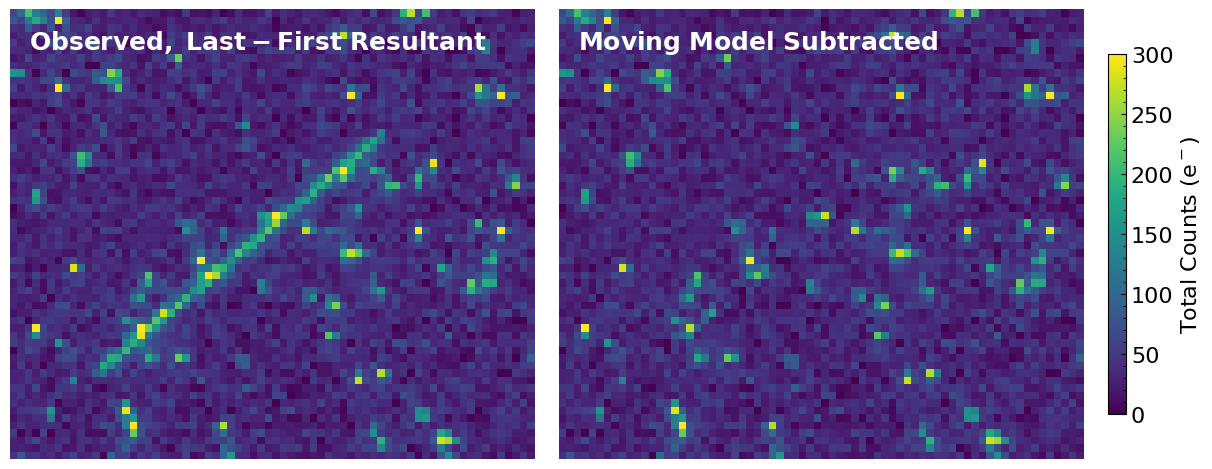

<Figure size 640x480 with 0 Axes>

In [5]:
# Make a figure showing the total counts

makefigure([values_resultants[-1], values_resultants[-1] - track.resultant_values[-1]],
           [r"${\bf Observed,~Last - First~Resultant}$", r"${\bf Moving~Model~Subtracted}$"],
           'Total Counts (e$^-$)', vmin=0, vmax=300)

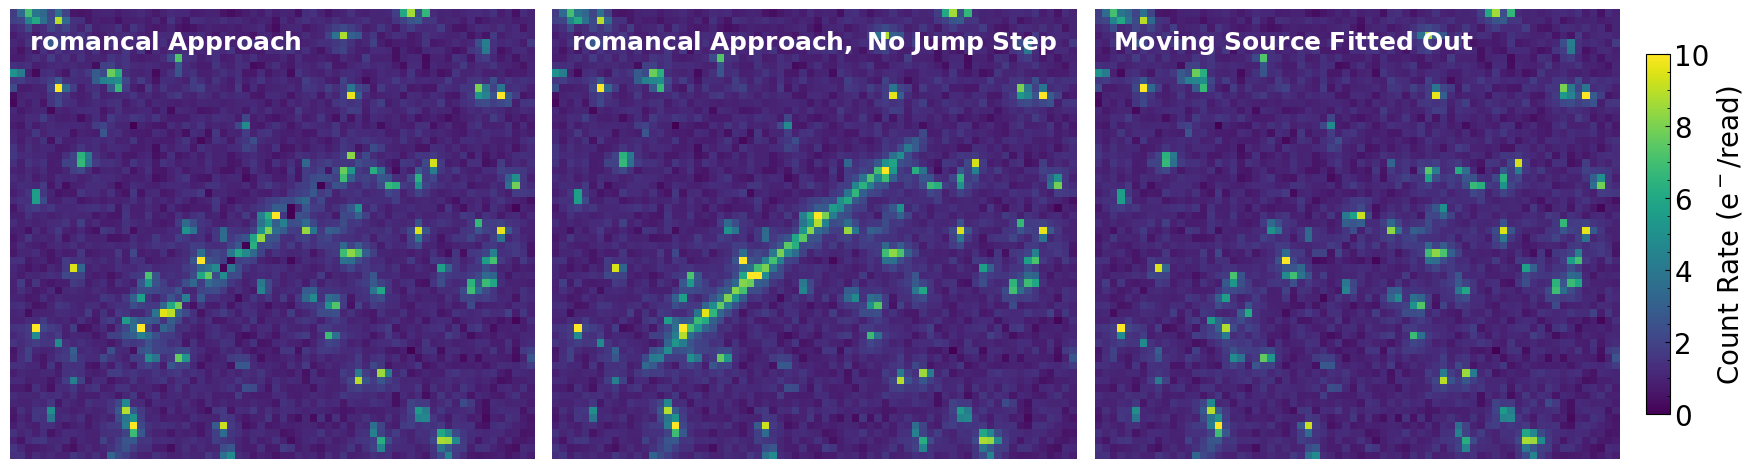

<Figure size 640x480 with 0 Axes>

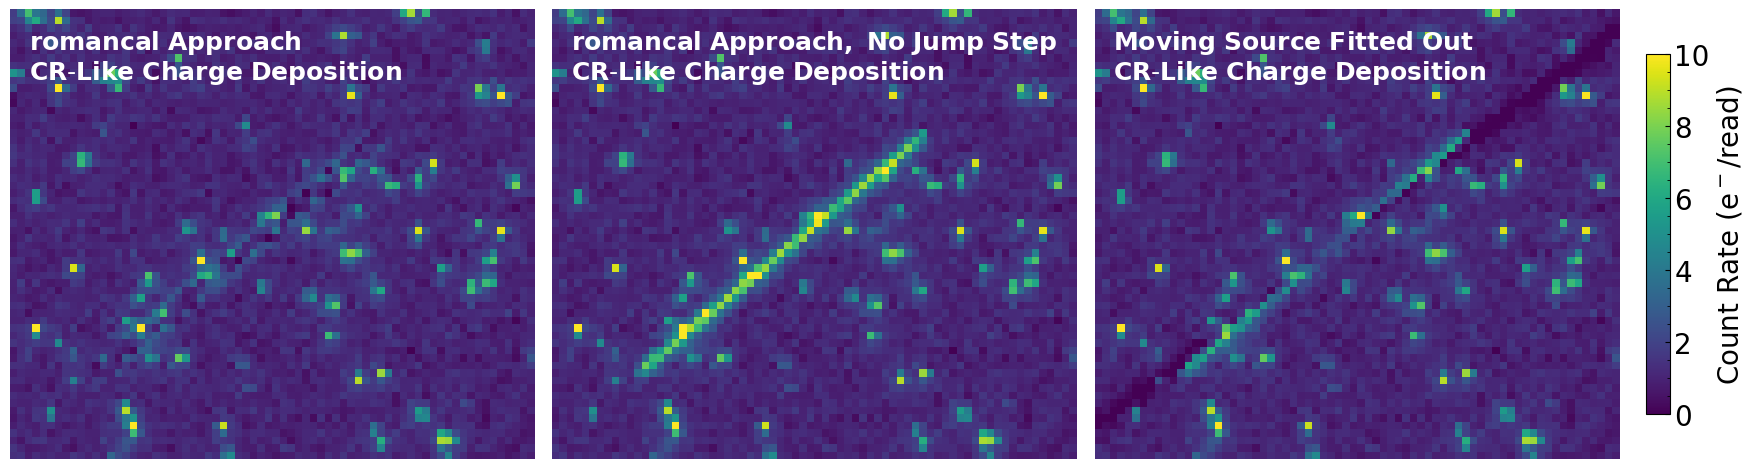

<Figure size 640x480 with 0 Axes>

In [6]:
# Now make a figure showing three panels and the behavior of romancal-style ramp fitting and jump detection

makefigure([ctrates_fitramp, ctrates_fitramp_nojumps, track.static_countrate],
           [r"${\bf romancal~Approach}$", r"${\bf romancal~Approach,~No~Jump~Step}$", r"${\bf Moving~Source~Fitted~Out}$"],
           'Count Rate (e$^-$/read)', vmin=0, vmax=10)

makefigure([ctrates_CR_fitramp, ctrates_CR_fitramp_nojumps, track_CRlike.static_countrate],
           [r"${\bf romancal~Approach}$", r"${\bf romancal~Approach,~No~Jump~Step}$", r"${\bf Moving~Source~Fitted~Out}$"],
           'Count Rate (e$^-$/read)', xtralabels=[r"${\bf CR}$-${\bf Like~Charge~Deposition}$"]*3,
           vmin=0, vmax=10)

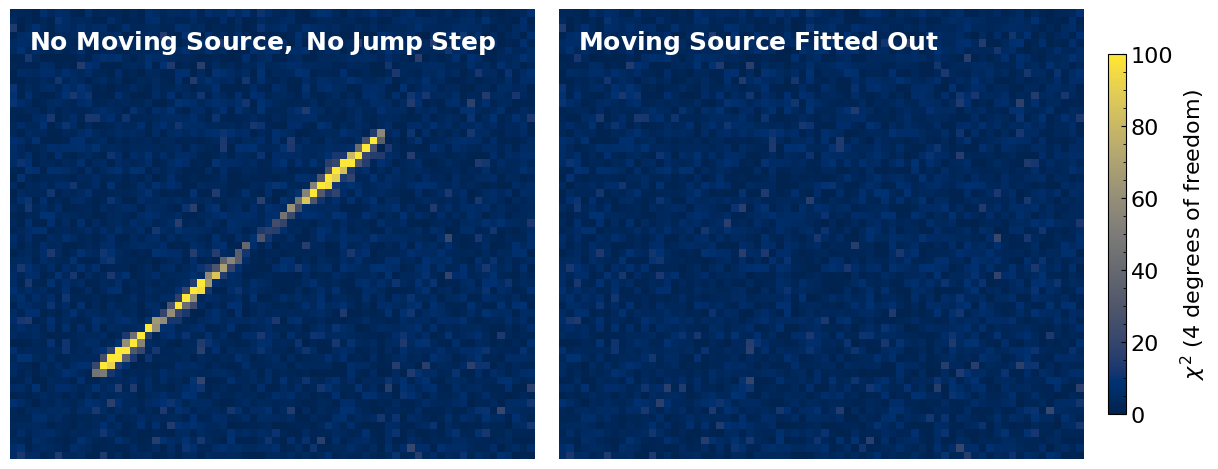

<Figure size 640x480 with 0 Axes>

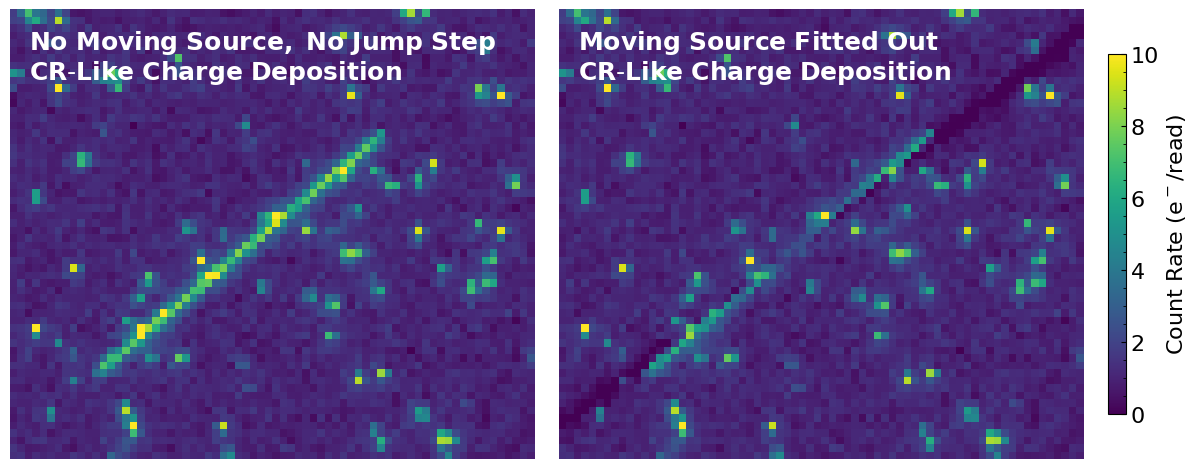

<Figure size 640x480 with 0 Axes>

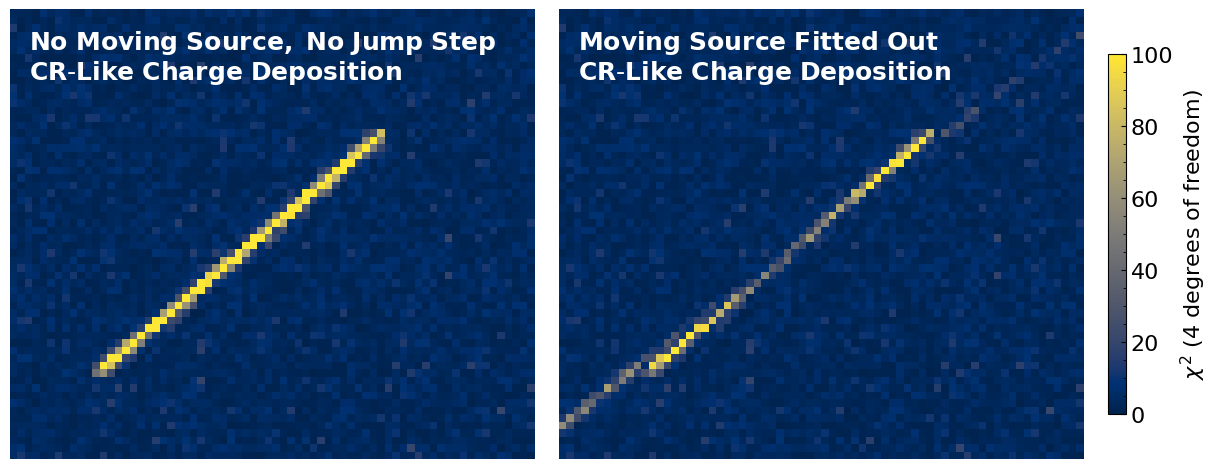

<Figure size 640x480 with 0 Axes>

In [7]:
# Chi squared improvement in the case of where the track is a moving source.  
# The chi squared values in the right panel (with the moving object fitted) are
# formally good given the four degrees of freedom (five resultant differences,
# with a single count rate to be fitted for each pixel).

makefigure([track.chisq_static, track.chisq_best],
           [r"${\bf No~Moving~Source,~No~Jump~Step}$", r"${\bf Moving~Source~Fitted~Out}$"],
           '$\chi^2$ (4 degrees of freedom)', vmin=0, vmax=100, cmap='cividis')

# Show that the fit is very poor if the same total charge is deposited at a 
# single instant in time rather than spread out over resultants.  

makefigure([track_CRlike.countrate_nomovingsource, track_CRlike.static_countrate],
           [r"${\bf No~Moving~Source,~No~Jump~Step}$", r"${\bf Moving~Source~Fitted~Out}$"],
           'Count Rate (e$^-$/read)', vmin=0, vmax=10,
           xtralabels=[r"${\bf CR}$-${\bf Like~Charge~Deposition}$"]*2)

# Chi squared improvement in the case where the track is all deposited in an 
# instant, similar to a cosmic ray.  The chi squared values are poor.

makefigure([track_CRlike.chisq_static, track_CRlike.chisq_best],
           [r"${\bf No~Moving~Source,~No~Jump~Step}$", r"${\bf Moving~Source~Fitted~Out}$"],
           '$\chi^2$ (4 degrees of freedom)', vmin=0, vmax=100,
           xtralabels=[r"${\bf CR}$-${\bf Like~Charge~Deposition}$"]*2, cmap='cividis')

Now regenerate a few figures showing the intuition of the modeling using an ePSF normalized to unit peak intensity.

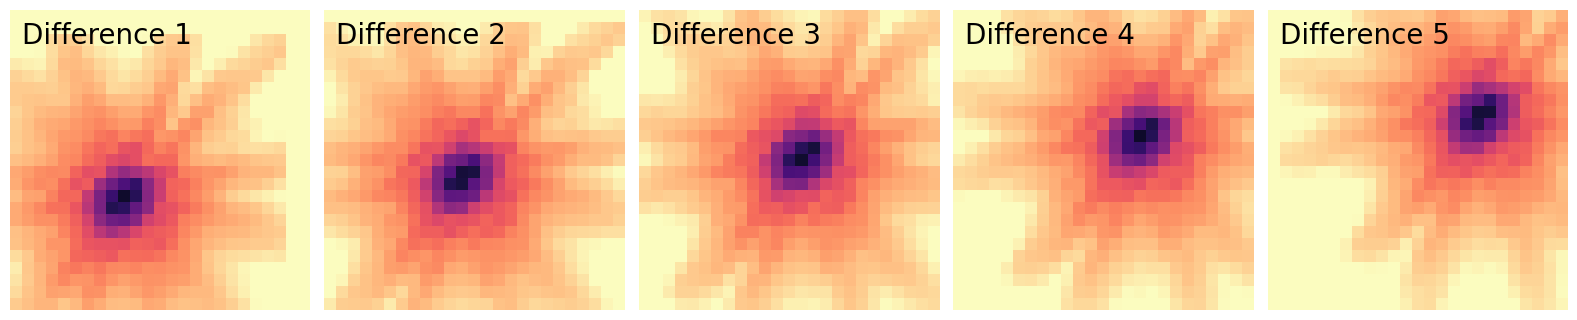

<Figure size 640x480 with 0 Axes>

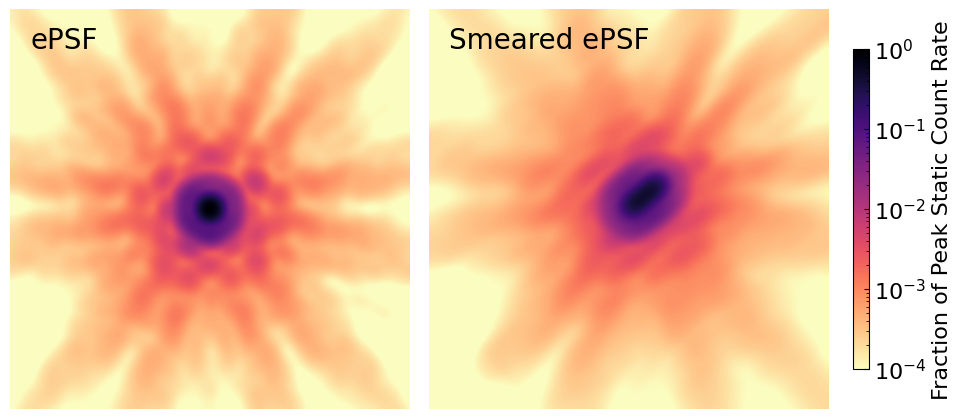

<Figure size 640x480 with 0 Axes>

In [8]:
# Roman ePSF, trimmed to 129x129 (=32x32 true pixels).
epsf = fits.open('roman_epsf_centered.fits')[0].data[116:-116, 116:-116]
epsf /= np.amax(epsf)
oversample = 4

phi = np.pi/3.6
dist = 2.7
outshape = (25, 25)

x0, y0 = 8, 8
readtimes = np.arange(1, 10)
resultants = [[i] for i in range(len(readtimes))]

track_sample = movingsource.MovingTrack(readtimes, resultants, epsf, oversample, outshape)
track_sample.gen_track([phi, dist, x0, y0], flux=1)

s1 = 15*1.04
fig = plt.figure(figsize=(s1, 3))
dx = 0.2/(1 - (0.2 - 3/s1))
for i in range(5):
    ax = fig.add_axes([i*dx, 0, 3/s1, 1])
    diff_value = track_sample.templates_reads[i]
    diff_value[diff_value <= 0] = 1e-100
    ax.imshow(diff_value, origin='lower', norm=LogNorm(vmin=1e-4, vmax=1), cmap='magma_r')
    ax.text(0.5, 23.5, "Difference %d" % (i + 1), color='k', verticalalignment='top', fontsize=20)
    ax.axis('off')
plt.show()
plt.clf()

fig = plt.figure(figsize=(9.5, 4))

dx = 4/9.5
ax1 = fig.add_axes([0, 0, dx, 1])
ax1.imshow(epsf[10:-10, 10:-10], origin='lower', interpolation='bicubic', norm=LogNorm(vmin=1e-4, vmax=1), cmap='magma_r')
ax1.text(5, epsf.shape[1] - 25, "ePSF", horizontalalignment='left', verticalalignment='top', fontsize=20)
ax1.axis('off')

fullim = movingsource.compute_smeared_image(epsf, phi, dist*oversample)
ax2 = fig.add_axes([dx + 0.02, 0, dx, 1])
ax2.text(5, epsf.shape[1] - 25, "Smeared ePSF", horizontalalignment='left', verticalalignment='top', fontsize=20)
ax2.axis('off')
_im = ax2.imshow(fullim[10:-10, 10:-10], origin='lower', interpolation='bicubic', norm=LogNorm(vmin=1e-4, vmax=1), cmap='magma_r')

cax = fig.add_axes([dx*2 + 0.045, 0.1, 0.2, 0.8])
cax.axis('off')
plt.colorbar(_im, label='Fraction of Peak Static Count Rate', ax=cax, pad=0, fraction=1, shrink=1, aspect=20)
plt.show()
plt.clf()

This time, use the full (large) ePSF and generate a track as resultant differences.

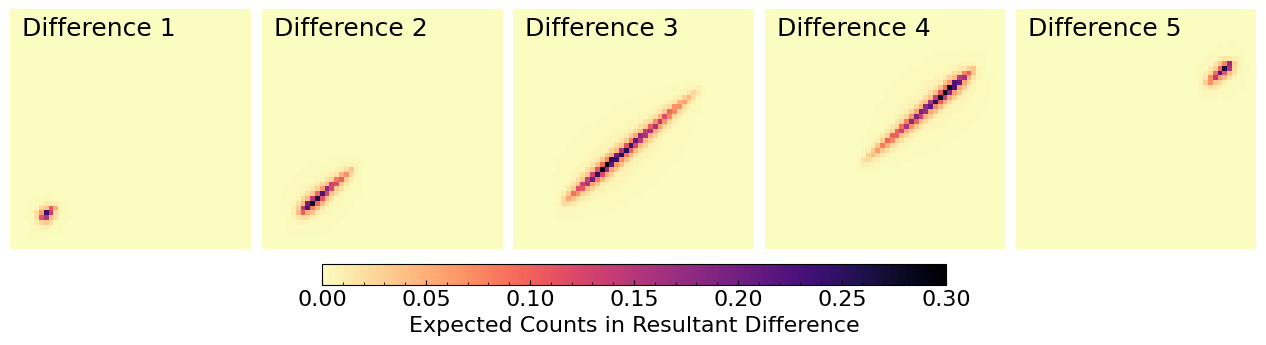

<Figure size 640x480 with 0 Axes>

In [9]:
epsf = fits.open('roman_epsf_centered.fits')[0].data
oversample = 4

readtimes = np.arange(1, 33)
resultants = [[0], [1, 2], [3, 4, 5, 6, 7, 8, 9, 10], 
              list(np.arange(11, 27)), [27, 28, 29, 30], [31]]

dist = 1.6           # Pixels/read
phi = np.pi/3.6      # Angle = 50 degrees
outshape = (50, 50)
x0, y0 = 5, 5        # Start at pixel (5, 5)

track_sample = movingsource.MovingTrack(readtimes, resultants, epsf, oversample, outshape)
track_sample.gen_track([phi, dist, x0, y0], flux=1)

# Machinery to make a tiled plot

s1 = 3*(len(resultants) - 1)*(1 + 0.01*(len(resultants) - 2))*0.8
s2 = 3*6/6*0.8

# 0.2 - 3/s1 is the fraction short
fig = plt.figure(figsize=(s1, s2*7/5))
dx = 0.2/(1 - (0.2 - s2/s1))
for i in range(len(resultants) - 1):
    ax = fig.add_axes([i*dx, 2/7, s2/s1, 5/7])
    _im = ax.imshow(track_sample.templates_resultants[i], origin='lower', vmin=0, vmax=0.3, cmap='magma_r')
    ax.text(2, 48, "Difference %d" % (i + 1), color='k', verticalalignment='top', fontsize=18)
    ax.axis('off')

cax = fig.add_axes([0.25, 0, 0.5, 1.7/7])
cax.axis('off')
plt.colorbar(_im, label='Expected Counts in Resultant Difference', ax=cax, 
             pad=0, fraction=1, shrink=1, aspect=30, orientation='horizontal')
plt.show()
plt.clf()